### Importeer de dataset

We gaan nu de sklearn library voor het neurale netwerk gebruiken om te runnen op onze dataset. 

Je kunt in de huiswerkopdracht van deze week kijken voor hints ( opdracht 3.2 )

In [11]:
# imports
import numpy as np;
import matplotlib.pyplot as plt
import random
from tensorflow.keras.datasets import mnist;


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

flattened_train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
flattened_test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255


### Labels representatie

Bedenk het volgende voor je mnist dataset:


- In welke range zijn de labels nu (wat is de min/max waarde)?

De labels zijn in een range van 0 tot en met 9

- Zijn de waardes numeriek of eigenlijk nominaal? Waarom?

Nominaal, je rekent er niet mee het is simpelweg een categorie.

- Waarom willen we dit omzetten naar een ander formaat?  

Zodat het Neuraal netwerk de labels makkelijker kan interpreteren.

We willen de **labels** omzetten naar een formaat die een NN beter kan interpreteren. Gebruik je hiervoor de OneHot Encoder? 

In [12]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encodeer de label
# sparse_output=False: resultaat na encoding is normale NumPy array
encoder = OneHotEncoder(sparse_output=False)

reshaped = train_labels.reshape(-1, 1)
train_labels_encoded = encoder.fit_transform(reshaped)


### Split test /training set

Ook hier moet je de test en de training set opspliten. Denk ook na over de representatie van je data. 


Als je pixelwaardes als parameters gebruikt, hoe ga je ze encoden?


### Simple NN: Layers opzet, architectuur

Gebruik keras van tensorflow om een neuraal netwerk op te zetten. De nieuwe manier om **keras** te gebruiken is:

    import tensorflow as tf
    model = tf.keras.Sequential([...])

Let op: voor sommigen zal de oude manier nog werken:


    from tensorflow import keras
    model = keras.Sequential([...])

Voeg de lagen van je neurale netwerk hier toe, dus tussen de blokhaken.
- Voeg de input layer toe. 

        tf.keras.Input(shape=(?,)),

Als parameter (?) kies het aantal input nodes. Hoeveel nodes kies je en waarom?

De aantal nodes moet gelijk staan aan de aantal pixels per afbeelding. in dit geval is dat dus n_features wat gelijk staat aan 784

- Voeg nu een hidden layer toe. Je kunt volgende code gebruiken

        tf.keras.layers.Dense("?", activation=?)

- Kies als eerste parameter ("?") het aantal nodes in deze layer. Hoeveel nodes kies je? Waarom?

Ik heb voor nu wat willekeurige getallen ingevoerd. ik ga achteraf door middel van trial & error deze waardes optimaliseren.

- Kies de activation. Wat was activation ook al weer? Voor nu kun je gewoon de ***relu*** gebruiken.

De activation is een formule die toegepast wordt op de output van elke neuron. Dit doe je om lineariteit te minimaliseren in je model

- Je kunt nog meer hidden layers toevoegen. Hoeveel hidden layers voeg je toe? 

Ik heb voor nu twee hidden layers. dit ga ik later finetunen

- Voeg nu de output layer toe. Code voor de output layer is hetzelfde als hidden, maar met een andere activatie functie. Hoeveel nodes kies je? Kies voor activation="softmax". Wat doet softmax ook al weer?

Softmax is een formule die de output van de laatste laag omzet in een kansverdeling

In [13]:
import tensorflow as tf

(n_samples, n_features) = flattened_train_images.shape


# Create a simple neural network model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(train_labels_encoded.shape[1], activation='softmax')  # output
])



### Compileer je model

Gebruik onderstaande code om je model te **compileren**

Wat compile doet: 

- Bepaalt hoe het model leert: adam optimizer
- Bepaalt wat het model probeert te minimaliseren: categorical crossentropy
- Bepaalt wat je wilt zien als prestatie‑indicator: 'accuracy' (bij ?)

Let er op dat je "loss" er niet bij hoeft te zetten omdat die zowieso als metric gebruikt wordt. 

- Wat is accuracy? Wat kun je er verder bij zetten?

De dingen die je hier instelt worden pas later gebruikt, namelijk in de volgende stap - als je 

    .fit 

doet.

In [14]:

# Je kunt het volgende stukje code uitbreiden 
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### Model trainen

Nu gaan we het model trainen. Bepaal hoeveel epochs je wilt doen en eg hoe groot de batch grootte is.

In [15]:
model.fit(flattened_train_images, train_labels_encoded, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8961 - loss: 0.3593
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9458 - loss: 0.1797
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9561 - loss: 0.1463
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9617 - loss: 0.1268
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9664 - loss: 0.1119


### Maak voorspellingen

Nu kunnen we voorspellingen maken. Gebruik de functie 

    .predict()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


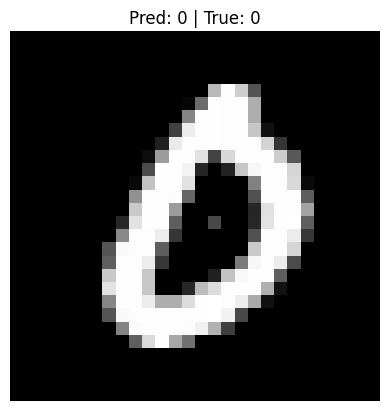

Random index: 7506
Voorspelde klasse: 0 vs echte klasse: 0
----------------------------------------


In [35]:
import matplotlib.pyplot as plt

random_index = random.randint(0, len(test_images) - 1)

# pak 1 image als batch
img = flattened_test_images[random_index:random_index + 1]

pred = model.predict(img)
predicted_class = pred.argmax()
true_class = test_labels[random_index]

# display image
plt.imshow(test_images[random_index], cmap='gray')
plt.title(f"Pred: {predicted_class} | True: {true_class}")
plt.axis("off")
plt.show()

print(f"Random index: {random_index}")
print(f"Voorspelde klasse: {predicted_class} vs echte klasse: {true_class}")
print("-" * 40)

### Experimenteer en onderzoek

Experimenteer nu zelf met verschillende settings / aantal hidden nodes / layers / activation functions en andere. Kijk of je algoritme beter en sneller kan voorspellen.